YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


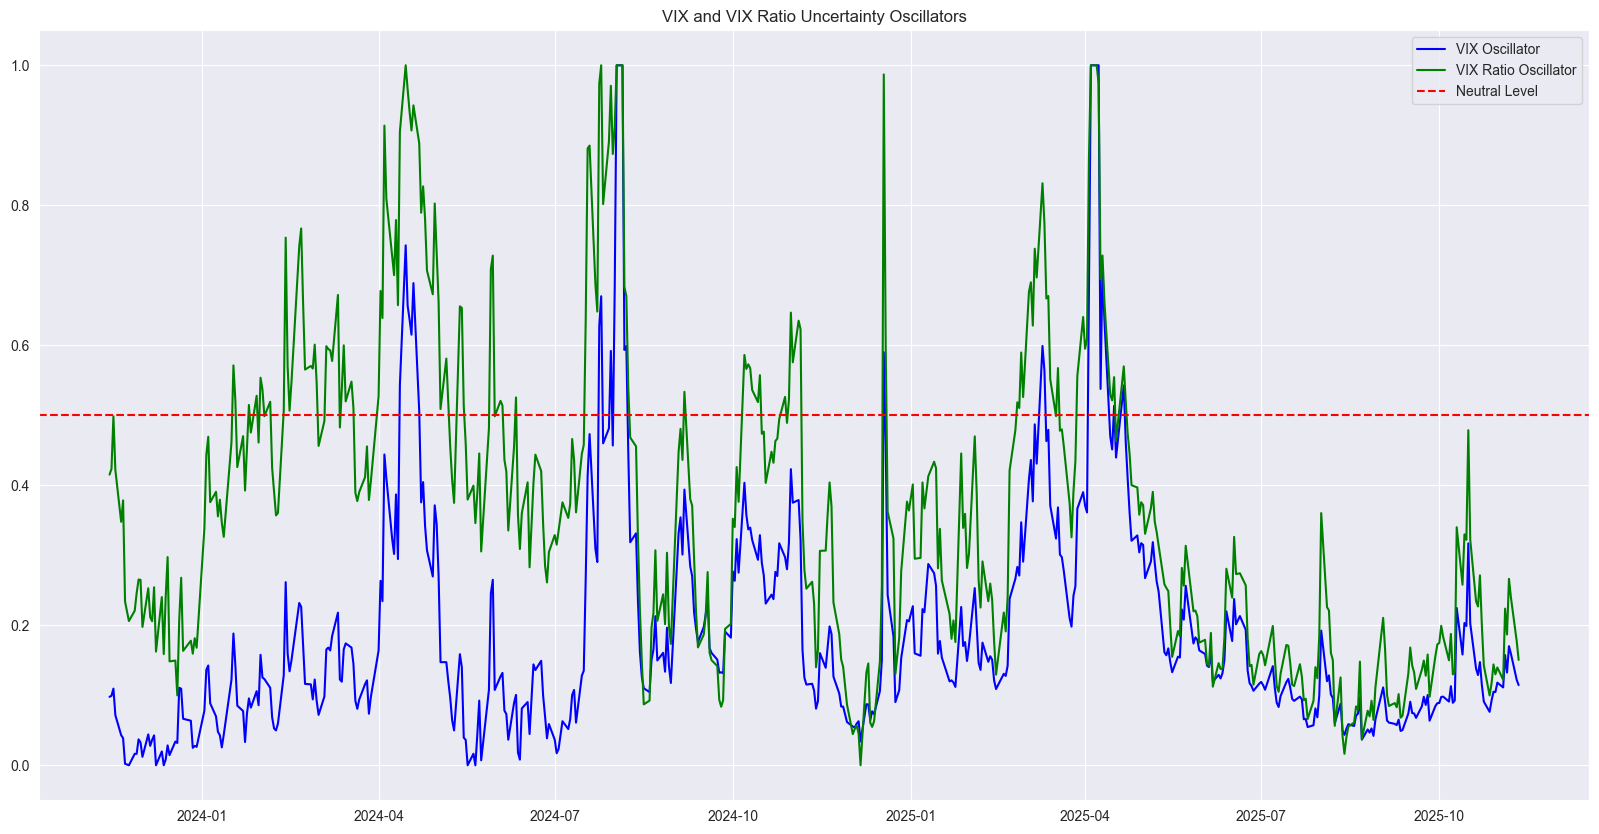

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch data from Yahoo Finance
tickers = ["^VIX", "^VIX3M", "^GSPC"]
data = yf.download(tickers, period="5y", interval="1d")['Close']

data.dropna(inplace=True)

# Compute the ratio between VIX 1M and VIX 1-3M
data['VIX_Ratio'] = data['^VIX'] / data['^VIX3M']

# Normalize the oscillators to a range of 0-1
window = 252  # 1-year rolling window

# VIX Oscillator
min_vix = data['^VIX'].rolling(window=window).min()
max_vix = data['^VIX'].rolling(window=window).max()
data['VIX_Oscillator'] = (data['^VIX'] - min_vix) / (max_vix - min_vix)

# VIX Ratio Oscillator
min_ratio = data['VIX_Ratio'].rolling(window=window).min()
max_ratio = data['VIX_Ratio'].rolling(window=window).max()
data['VIX_Ratio_Oscillator'] = (data['VIX_Ratio'] - min_ratio) / (max_ratio - min_ratio)
sample_data = data.iloc[-500:,:]
# Plot the oscillators
plt.figure(figsize=(20, 10))
plt.plot(sample_data.index, sample_data['VIX_Oscillator'], label='VIX Oscillator', color='blue')
plt.plot(sample_data.index, sample_data['VIX_Ratio_Oscillator'], label='VIX Ratio Oscillator', color='green')
plt.axhline(0.5, color='red', linestyle='--', label='Neutral Level')
plt.title("VIX and VIX Ratio Uncertainty Oscillators")
plt.legend()
plt.show()

/Users/ob/Desktop/BackTesting/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: xlabel='Date'>

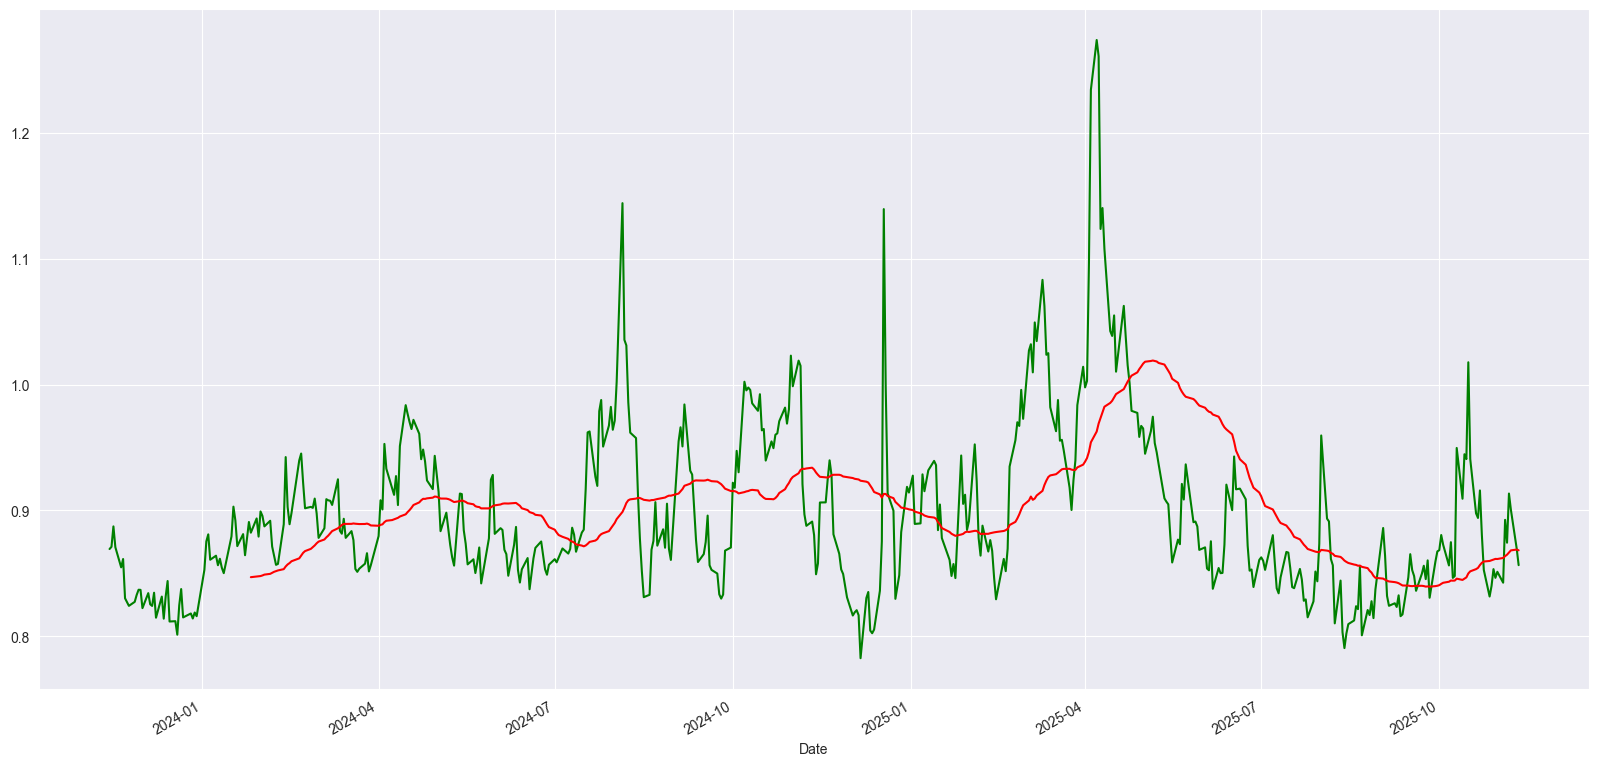

In [8]:
plt.figure(figsize=(20, 10))
plt.plot(sample_data.index, sample_data['VIX_Ratio'], label='VIX Ratio (VIX/VIX3M)', color='green')
sample_data['VIX_Ratio'].rolling(50).mean().plot(color='red')
# plt.plot(sample_data.index, sample_data['VIX_Ratio'], label='VIX Ratio (VIX/VIX3M)', color='red')

/var/folders/b2/j7lwm8n16zz16xz_l2_qz55h0000gn/T/ipykernel_97307/4158445717.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  backtest['Position'] = np.where(signal, 1, 0)  # 1 = Invested in S&P 500, 0 = Cash
/var/folders/b2/j7lwm8n16zz16xz_l2_qz55h0000gn/T/ipykernel_97307/4158445717.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  backtest['SP500_Return'] = backtest['^GSPC'].pct_change()
/var/folders/b2/j7lwm8n16zz16xz_l2_qz55h0000gn/T/ipykernel_97307/4158445717.py:11: SettingWithCopyWarning: 
A value

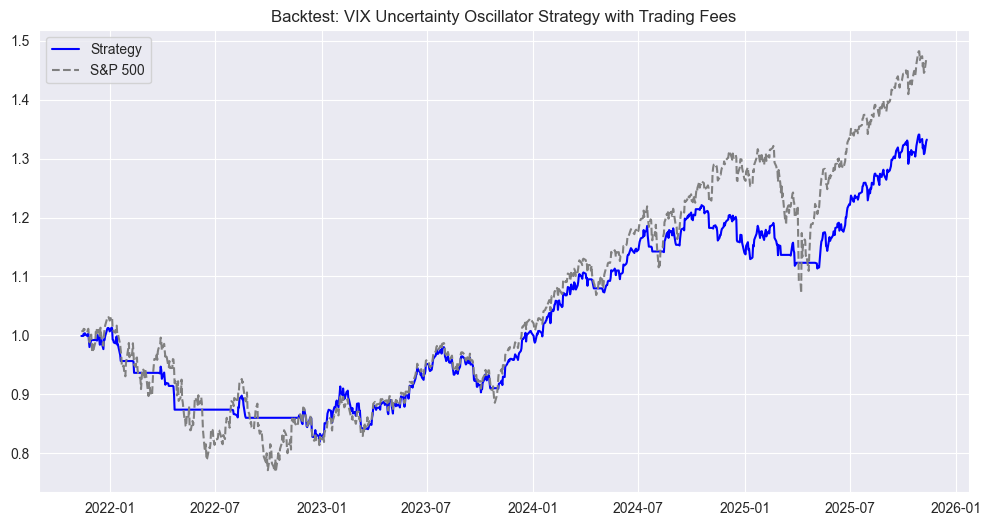

In [3]:
# Backtesting strategy with trading fee
trading_fee = 0.001  # 0.1% fee per trade
backtest = data.dropna()
signal = backtest['VIX_Oscillator'].shift(1) < 0.3  # Buy when oscillator is below 0.5 (with one-day lag)
backtest['Position'] = np.where(signal, 1, 0)  # 1 = Invested in S&P 500, 0 = Cash

backtest['SP500_Return'] = backtest['^GSPC'].pct_change()
trades = backtest['Position'].diff().abs()  # Detect position changes (entries/exits)

# Apply trading fees when switching positions
backtest['Strategy_Return'] = backtest['Position'].shift(1) * backtest['SP500_Return'] - trades * trading_fee

backtest['Cumulative_Strategy'] = (1 + backtest['Strategy_Return']).cumprod()
backtest['Cumulative_SP500'] = (1 + backtest['SP500_Return']).cumprod()

# Plot the strategy performance
plt.figure(figsize=(12, 6))
plt.plot(backtest.index, backtest['Cumulative_Strategy'], label='Strategy', color='blue')
plt.plot(backtest.index, backtest['Cumulative_SP500'], label='S&P 500', color='gray', linestyle='--')
plt.title("Backtest: VIX Uncertainty Oscillator Strategy with Trading Fees")
plt.legend()
plt.show()

In [4]:
backtest

Ticker,^GSPC,^VIX,^VIX3M,VIX_Ratio,VIX_Oscillator,VIX_Ratio_Oscillator,Position,SP500_Return,Strategy_Return,Cumulative_Strategy,Cumulative_SP500
Date,,,,,,,,,,,
2021-11-11,4649.270020,17.660000,21.379999,0.826006,0.119369,0.251603,0,NaN,NaN,NaN,NaN
2021-11-12,4682.850098,16.290001,20.690001,0.787337,0.057658,0.117261,1,0.007223,-0.001000,0.999000,1.007223
2021-11-15,4682.799805,16.490000,20.870001,0.790129,0.066667,0.126962,1,-0.000011,-0.000011,0.998989,1.007212
2021-11-16,4700.899902,16.370001,20.900000,0.783254,0.061261,0.103075,1,0.003865,0.003865,1.002851,1.011105
2021-11-17,4688.669922,17.110001,21.580000,0.792864,0.094595,0.136462,1,-0.002602,-0.002602,1.000242,1.008474
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-05,6796.290039,18.010000,20.600000,0.874272,0.132457,0.186811,1,0.003654,0.003654,1.322379,1.461797
2025-11-06,6720.319824,19.500000,21.350000,0.913349,0.170121,0.266335,1,-0.011178,-0.011178,1.307597,1.445457
2025-11-07,6728.799805,19.080000,21.190001,0.900425,0.159505,0.240034,1,0.001262,0.001262,1.309247,1.447281


In [5]:
sample_data

Ticker,^GSPC,^VIX,^VIX3M,VIX_Ratio,VIX_Oscillator,VIX_Ratio_Oscillator
Date,,,,,,
2023-11-14,4495.700195,14.160000,16.290001,0.869245,0.097810,0.415252
2023-11-15,4502.879883,14.180000,16.280001,0.871007,0.099270,0.423415
2023-11-16,4508.240234,14.320000,16.139999,0.887237,0.109489,0.498584
2023-11-17,4514.020020,13.800000,15.850000,0.870662,0.071533,0.421818
2023-11-20,4547.379883,13.410000,15.690000,0.854685,0.043066,0.347814
...,...,...,...,...,...,...
2025-11-05,6796.290039,18.010000,20.600000,0.874272,0.132457,0.186811
2025-11-06,6720.319824,19.500000,21.350000,0.913349,0.170121,0.266335
2025-11-07,6728.799805,19.080000,21.190001,0.900425,0.159505,0.240034
